# HAR TFM

In [4]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

ruta_archivo_csv = "../../Procesamiento Datos/Dataset/HAR_TFM.csv.gz"

df = pd.read_csv(ruta_archivo_csv)
print(df)

              Ax        Ay        Az       Gx        Gy        Gz          Mx  \
0       0.028037  0.272983  0.938547 -0.85745  1.530512 -1.285625   16.856251   
1       0.036297 -1.118226 -0.264005 -0.61710  0.379362 -0.267025  362.943756   
2       0.032427  0.145508  1.354897 -1.07635 -1.441825  0.696025    0.356250   
3       0.370183  0.204207  0.954832 -0.37954 -0.559665 -0.238312  -25.068750   
4       1.329001 -0.985352  0.107682  1.72095 -1.653575 -1.253725  -39.600002   
...          ...       ...       ...      ...       ...       ...         ...   
365995  0.177876  0.465430  0.859490 -0.09094  0.068109  0.005574  -19.800001   
365996  0.351190 -0.832287 -0.448884 -0.00990 -0.000825  0.009762   32.812500   
365997  1.014918 -0.141639  0.255638  0.01265  0.007700  0.000137    3.187500   
365998  1.009626 -0.294183 -0.150097  0.02640  0.024750  0.030938   36.000000   
365999  0.230048 -0.802216 -0.552589 -0.00770 -0.023100 -0.003025  -15.356251   

               My         M

# Modelo Support-Vector Machines (SVM)

In [5]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','AyMx','AzMx','Gz']

In [6]:
#Para ver la mayor corelación
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 366000
Número de columnas: 22


In [7]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
#from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import time

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Paso 5: Crear y entrenar el modelo SVM
svm_model = LinearSVC(random_state=42)

# Inicio del entrenamiento
inicio = time.time()

svm_model.fit(X_train, y_train)

# Fin del entrenamiento
fin = time.time()

tiempo_entrenamiento_svm = fin - inicio

# Paso 6: Evaluar el modelo en el conjunto de prueba 
accuracy = svm_model.score(X_test, y_test)
print("Accuracy:", accuracy)
print(f"Tiempo de entrenamiento del SVM: {tiempo_entrenamiento_svm/60:.2f} minutos")

/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Accuracy: 0.47577868852459015
Tiempo de entrenamiento del SVM: 8.25 minutos


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Realizar las predicciones en el conjunto de prueba
y_pred = svm_model.predict(X_test)

# Calcular las métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)


Accuracy: 0.47577868852459015
Precision: 0.6262809722422229
Recall: 0.47577868852459015
F1 Score: 0.4459181665669829


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels = ['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(Labels)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test == label_idx).astype(int)
    y_pred_label = (y_pred == label_idx).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()


Label: Caminar
Accuracy: 0.8520355191256831
Precision: 0.5802172670097199
Recall: 0.4147457904201406
F1 Score: 0.4837218170551504

Label: Metro
Accuracy: 0.8390983606557377
Precision: 0.8853333333333333
Recall: 0.02751305212563189
F1 Score: 0.05336762578363607

Label: Bus
Accuracy: 0.6207103825136612
Precision: 0.2829687237732893
Recall: 0.8258491182233834
F1 Score: 0.42151102221110975

Label: Conducir coche
Accuracy: 0.9102868852459016
Precision: 0.7032294778773652
Recall: 0.8049833075482452
F1 Score: 0.7506739056152474

Label: Subir o bajar escaleras
Accuracy: 0.8758606557377049
Precision: 0.6761331364307622
Recall: 0.48834919593042336
F1 Score: 0.5671001857939116

Label: Estar detenido
Accuracy: 0.8535655737704918
Precision: 0.6336561300931848
Recall: 0.28468231817435563
F1 Score: 0.39286321155480036



## Matriz de confusión

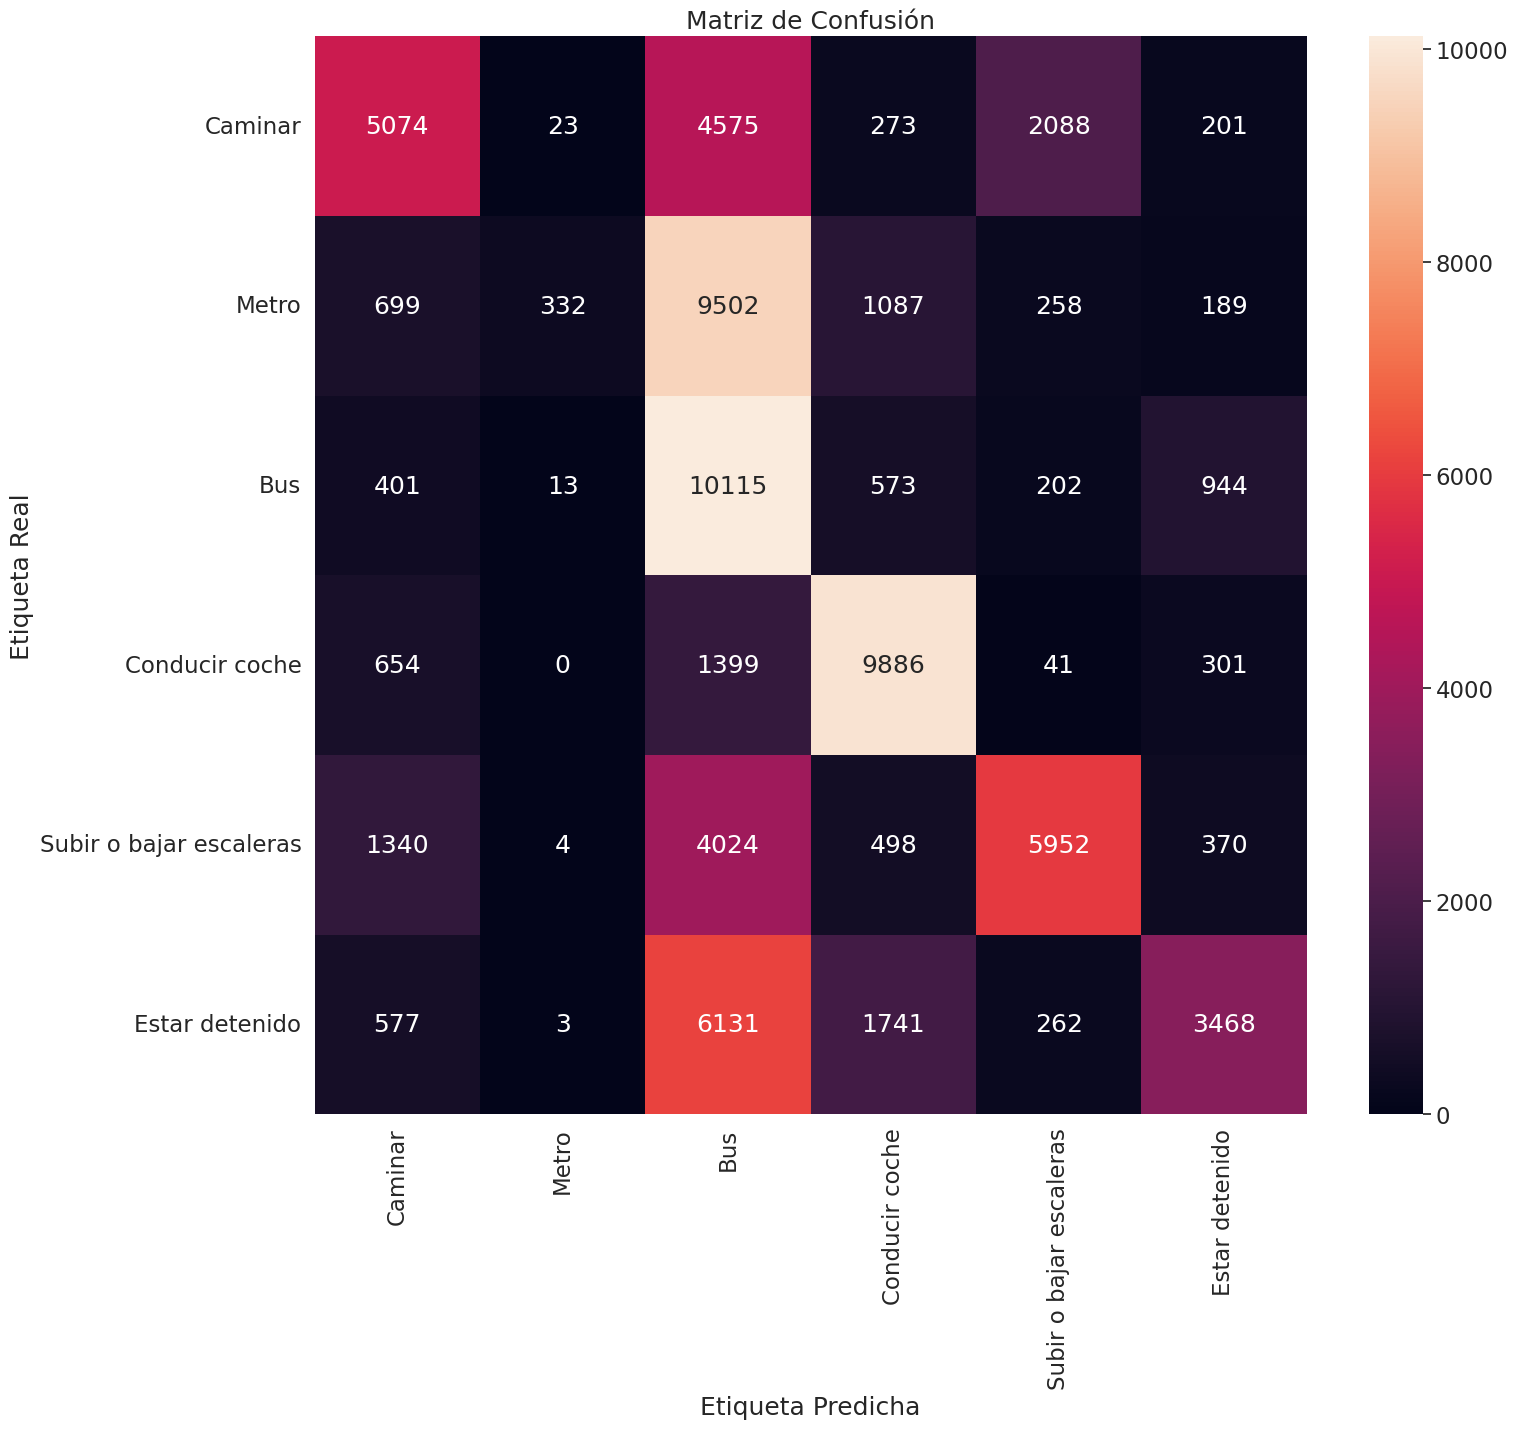

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


Labels = ['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Calcular la matriz de confusión
confusion_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

plt.figure(figsize=(16, 14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True, fmt='d')
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()


In [11]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_test, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 12234, Actividad: Caminar
Valor: 1, Cantidad: 12067, Actividad: Metro
Valor: 2, Cantidad: 12248, Actividad: Bus
Valor: 3, Cantidad: 12281, Actividad: Conducir coche
Valor: 4, Cantidad: 12188, Actividad: Subir o bajar escaleras
Valor: 5, Cantidad: 12182, Actividad: Estar detenido


# Exportamos el modelo

In [12]:
import joblib
# Paso 7: Guardar el modelo y el codificador de etiquetas
joblib.dump(svm_model, '../../Datos/Modelos/svm_model.pkl')
joblib.dump(label_encoder, '../../Datos/Label/label_encoder.pkl')

['../../Datos/Label/label_encoder.pkl']